# Agentic AI Fundamentals

## Notebook 12: MCP Fundamentals: Tools, Resources, and Prompts

Model Context Protocol, usually shortened to MCP, standardizes how an AI application discovers and uses capabilities supplied by another component. Instead of writing a custom integration for every tool provider, an MCP client can ask a server what it exposes, inspect the schemas, and invoke those capabilities through a shared protocol.

This notebook uses the stable MCP Python SDK v2. We will create a real MCP server and client inside one Colab notebook, discover tools, read resources, retrieve prompts, handle protocol errors, and finally let Gemini select a tool that is executed through MCP. No external Python file or background process is required for the lesson.

## Learning objectives

By the end of this notebook, you should be able to:

- explain the roles of an MCP host, client, and server;
- distinguish tools, resources, and prompts;
- create a typed MCP server with the official Python SDK;
- connect a client and perform capability discovery;
- invoke tools and inspect structured results;
- read static and parameterized resources;
- retrieve server-provided prompt templates;
- understand transport and trust-boundary choices; and
- bridge discovered MCP tools to a real LLM safely.

## 1. The MCP architecture

| Component | Responsibility | In this notebook |
|---|---|---|
| Host | Owns the user experience, model, policy, and permissions | Our notebook application |
| Client | Maintains a protocol connection to one MCP server | `mcp.Client` |
| Server | Publishes capabilities backed by data or application logic | `course_server` |
| Transport | Carries protocol messages | In-process for the lesson |

A host may create several MCP clients, each connected to a different server. The server does not become the agent and does not decide what the user wants. It exposes capabilities; the host decides what the model may see and whether a requested action should execute.

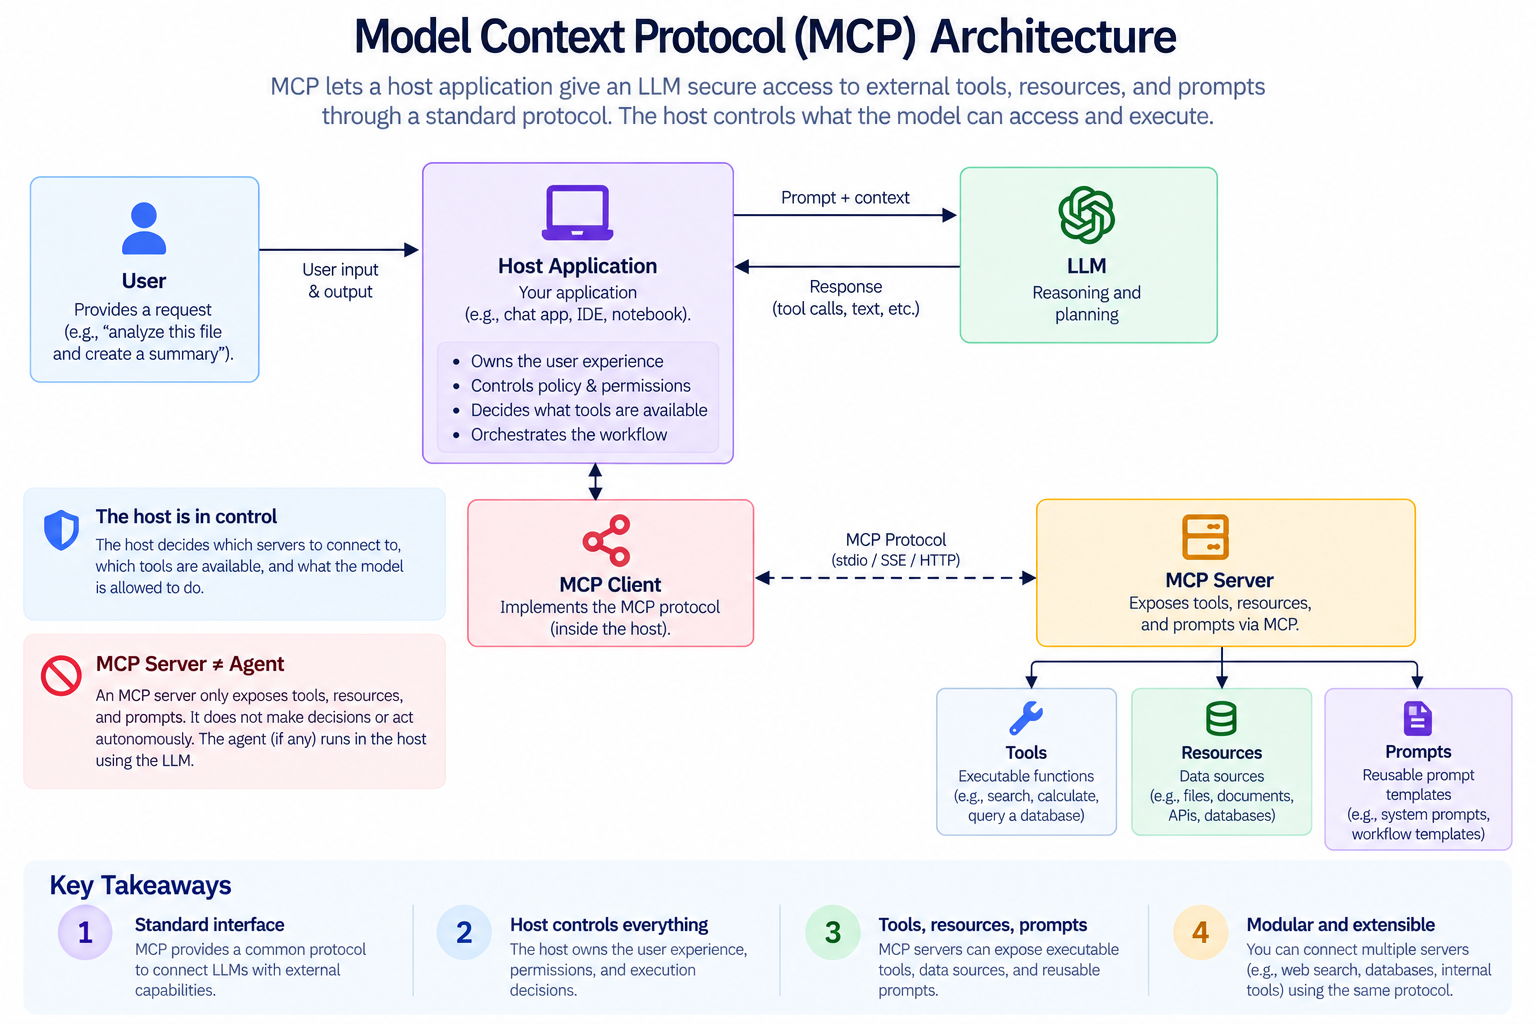

Each client-server connection has its own lifecycle and trust boundary. Capability discovery makes integrations portable, but it does not remove the need for authorization, validation, logging, or human approval.

## 2. Tools, resources, and prompts

| Primitive | Mental model | Typical use |
|---|---|---|
| Tool | An operation that may compute or act | Search, calculate, create a ticket |
| Resource | Addressable context identified by a URI | A document, schema, record, or log |
| Prompt | A reusable message template | A review workflow or domain instruction |

A useful rule is that a model usually **chooses tools**, the application usually **selects resources**, and a user or application usually **selects prompts**. Implementations can vary, but this distinction prevents every piece of context from being misrepresented as a function call.

## 3. Install the stable SDK

The tutorial pins the major version because MCP Python SDK v2 introduced breaking changes from v1. A major-version bound keeps the notebook reproducible while allowing compatible v2 updates.

In [ ]:
%pip install -q -U "mcp>=2,<3" "google-genai>=1.0.0" "pydantic>=2.7,<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [ ]:
import json
import re
from typing import Any

from mcp import Client as MCPClient
from mcp.server import MCPServer

## 4. Create an in-process MCP server

Normally a server runs as a separate process or service. The v2 client can also connect directly to an `MCPServer` object, which is ideal for a self-contained Colab lesson. The protocol lifecycle and discovery calls remain real; only the network transport is removed.

Our server represents a tiny course service. It will expose typed functions and course material while keeping the underlying dictionaries private.

In [ ]:
course_server = MCPServer(
    name="agentic-ai-course",
    title="Agentic AI Course Server",
    description="Tools and resources for the Agentic AI Fundamentals course.",
    version="1.0.0",
)


COURSE_NOTES = {
    "agents": (
        "An agent lets a model choose actions within an application-controlled "
        "loop. The runtime validates and executes those actions."
    ),
    "guardrails": (
        "Guardrails should be layered across input, model output, tool policy, "
        "execution, and final response boundaries."
    ),
    "evaluation": (
        "Agent evaluation should measure outcomes, trajectories, safety, cost, "
        "and latency rather than relying on one aggregate score."
    ),
    "mcp": (
        "MCP standardizes capability discovery and communication between hosts, "
        "clients, and servers."
    ),
}


LESSONS = {
    "09": "Guardrails, human approval, and failure recovery.",
    "10": "Agent evaluation, tracing, cost, and latency.",
    "11": "Multi-agent delegation, handoffs, and coordination.",
    "12": "MCP tools, resources, prompts, and client integration.",
}

## 5. Publish tools from typed Python functions

The SDK derives each tool's input schema from Python type annotations and its description from the docstring. This eliminates duplicated hand-written JSON Schema, but good names, types, and documentation still matter because both clients and models rely on them.

In [ ]:
@course_server.tool()
def search_course_notes(query: str, max_results: int = 3) -> list[dict[str, str]]:
    '''Search course notes for a topic and return the most relevant passages.'''
    if not 1 <= max_results <= 5:
        raise ValueError("max_results must be between 1 and 5")

    terms = set(re.findall(r"[a-z]+", query.lower()))
    scored = []
    for topic, text in COURSE_NOTES.items():
        searchable = set(re.findall(r"[a-z]+", f"{topic} {text}".lower()))
        score = len(terms & searchable)
        if score:
            scored.append((score, topic, text))

    scored.sort(reverse=True)
    return [
        {"topic": topic, "text": text}
        for _, topic, text in scored[:max_results]
    ]


@course_server.tool()
def calculate_percentage_change(old_value: float, new_value: float) -> dict[str, float]:
    '''Calculate percentage change from an old value to a new value.'''
    if old_value == 0:
        raise ValueError("old_value cannot be zero")
    change = ((new_value - old_value) / old_value) * 100
    return {"percentage_change": round(change, 4)}

These tools are read-only and deterministic. A production server may expose side-effecting tools, but MCP does not make those actions safe automatically. The host still needs allowlists, user authorization, risk classification, approval, and audit logging—the controls we built in Notebook 09.

## 6. Publish resources

A resource is addressed by a URI. Static resources have fixed URIs, while resource templates contain parameters. Here, the syllabus is static and individual lessons use a template.

In [ ]:
@course_server.resource("course://syllabus")
def syllabus() -> str:
    '''Return the available course lessons.'''
    return "\n".join(
        f"Lesson {lesson_id}: {title}"
        for lesson_id, title in LESSONS.items()
    )


@course_server.resource("course://lessons/{lesson_id}")
def lesson(lesson_id: str) -> str:
    '''Return a lesson summary by its two-digit identifier.'''
    if lesson_id not in LESSONS:
        raise ValueError(f"Unknown lesson: {lesson_id}")
    return LESSONS[lesson_id]

## 7. Publish a prompt template

Prompts let a server distribute reusable interaction templates without executing a model. Retrieving a prompt returns messages that the host may inspect, modify, approve, or send to its chosen model.

In [ ]:
@course_server.prompt()
def review_lesson(topic: str, experience_level: str = "beginner") -> str:
    '''Create instructions for reviewing one course topic.'''
    return (
        f"Review the topic '{topic}' for a {experience_level} reader. "
        "Explain the core idea, give one concrete example, identify one common "
        "mistake, and finish with two self-check questions."
    )

At this point we have declared server capabilities, but we have not called them through MCP. Calling the underlying Python function directly would test business logic; connecting an MCP client tests discovery, protocol validation, serialization, and results.

## 8. Connect a client and discover capabilities

Notebook cells support top-level `await`, so we can use the asynchronous client without workarounds. Entering the client context performs the connection lifecycle and initialization handshake.

In [ ]:
async def discover_course_server() -> dict[str, Any]:
    async with MCPClient(course_server) as client:
        tools = await client.list_tools()
        resources = await client.list_resources()
        templates = await client.list_resource_templates()
        prompts = await client.list_prompts()

        return {
            "server": client.server_info.model_dump(),
            "tools": [tool.model_dump() for tool in tools.tools],
            "resources": [resource.model_dump() for resource in resources.resources],
            "resource_templates": [
                template.model_dump()
                for template in templates.resource_templates
            ],
            "prompts": [prompt.model_dump() for prompt in prompts.prompts],
        }


discovery = await discover_course_server()
print(json.dumps(discovery, indent=2, default=str))

{
  "server": {
    "name": "agentic-ai-course",
    "title": "Agentic AI Course Server",
    "version": "1.0.0",
    "description": "Tools and resources for the Agentic AI Fundamentals course.",
    "website_url": null,
    "icons": null
  },
  "tools": [
    {
      "name": "search_course_notes",
      "title": null,
      "description": "Search course notes for a topic and return the most relevant passages.",
      "input_schema": {
        "type": "object",
        "properties": {
          "query": {
            "title": "Query",
            "type": "string"
          },
          "max_results": {
            "default": 3,
            "title": "Max Results",
            "type": "integer"
          }
        },
        "required": [
          "query"
        ],
        "title": "search_course_notesArguments"
      },
      "execution": null,
      "output_schema": {
        "properties": {
          "result": {
            "items": {
              "additionalProperties": {
        

Notice that discovery returns names, descriptions, and JSON-compatible schemas. A host can use this information to construct a tool registry dynamically instead of importing the server's Python functions.

Dynamic discovery does not mean “automatically trust everything.” A serious host filters capabilities against configuration and policy before showing them to a model.

## 9. Call tools through MCP

`call_tool` returns protocol content and, when the tool declares a structured output, `structured_content`. Application logic should prefer the structured form instead of parsing display text.

In [ ]:
async def run_tool_examples() -> dict[str, Any]:
    async with MCPClient(course_server) as client:
        search_result = await client.call_tool(
            "search_course_notes",
            {"query": "agent evaluation safety", "max_results": 2},
        )
        calculation_result = await client.call_tool(
            "calculate_percentage_change",
            {"old_value": 80, "new_value": 92},
        )

        return {
            "search": search_result.structured_content,
            "calculation": calculation_result.structured_content,
            "search_is_error": search_result.is_error,
            "calculation_is_error": calculation_result.is_error,
        }


tool_examples = await run_tool_examples()
print(json.dumps(tool_examples, indent=2))

{
  "search": {
    "result": [
      {
        "topic": "evaluation",
        "text": "Agent evaluation should measure outcomes, trajectories, safety, cost, and latency rather than relying on one aggregate score."
      },
      {
        "topic": "agents",
        "text": "An agent lets a model choose actions within an application-controlled loop. The runtime validates and executes those actions."
      }
    ]
  },
  "calculation": {
    "percentage_change": 15.0
  },
  "search_is_error": false,
  "calculation_is_error": false
}


The percentage result is `15`: moving from 80 to 92 is a 12-point absolute increase and a 15-percent relative increase. Precise tool descriptions and output field names help prevent those two quantities from being confused.

## 10. Read resources and retrieve prompts

Resources and prompts travel through different protocol methods because they represent different intentions. Reading a resource obtains content at a URI; getting a prompt renders a named template with arguments.

In [ ]:
async def run_context_examples() -> dict[str, Any]:
    async with MCPClient(course_server) as client:
        syllabus_result = await client.read_resource("course://syllabus")
        lesson_result = await client.read_resource("course://lessons/12")
        prompt_result = await client.get_prompt(
            "review_lesson",
            {"topic": "MCP resources", "experience_level": "beginner"},
        )

        return {
            "syllabus": syllabus_result.contents[0].text,
            "lesson": lesson_result.contents[0].text,
            "prompt_messages": [
                message.model_dump() for message in prompt_result.messages
            ],
        }


context_examples = await run_context_examples()
print(json.dumps(context_examples, indent=2))

{
  "syllabus": "Lesson 09: Guardrails, human approval, and failure recovery.\nLesson 10: Agent evaluation, tracing, cost, and latency.\nLesson 11: Multi-agent delegation, handoffs, and coordination.\nLesson 12: MCP tools, resources, prompts, and client integration.",
  "lesson": "MCP tools, resources, prompts, and client integration.",
  "prompt_messages": [
    {
      "role": "user",
      "content": {
        "type": "text",
        "text": "Review the topic 'MCP resources' for a beginner reader. Explain the core idea, give one concrete example, identify one common mistake, and finish with two self-check questions.",
        "annotations": null,
        "meta": null
      }
    }
  ]
}


## 11. Treat protocol errors as normal results

Models can produce malformed arguments or request a capability that disappeared after discovery. With `raise_exceptions=False`, tool failures are returned as structured MCP results with `is_error=True`. The host can record the failure, decide whether a retry is safe, or return the observation to the model.

In [ ]:
async def demonstrate_tool_errors() -> list[dict[str, Any]]:
    async with MCPClient(course_server, raise_exceptions=False) as client:
        invalid_arguments = await client.call_tool(
            "calculate_percentage_change",
            {"old_value": "not-a-number", "new_value": 92},
        )
        unknown_tool = await client.call_tool("delete_course", {})

        return [
            {
                "case": "invalid_arguments",
                "is_error": invalid_arguments.is_error,
                "message": invalid_arguments.content[0].text,
            },
            {
                "case": "unknown_tool",
                "is_error": unknown_tool.is_error,
                "message": unknown_tool.content[0].text,
            },
        ]


tool_errors = await demonstrate_tool_errors()
print(json.dumps(tool_errors, indent=2))

[
  {
    "case": "invalid_arguments",
    "is_error": true,
    "message": "Error executing tool calculate_percentage_change: 1 validation error for calculate_percentage_changeArguments\nold_value\n  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='not-a-number', input_type=str]\n    For further information visit https://errors.pydantic.dev/2.13/v/float_parsing"
  },
  {
    "case": "unknown_tool",
    "is_error": true,
    "message": "Unknown tool: delete_course"
  }
]


Do not send raw exception details directly to end users in production. They can reveal implementation information. Preserve detailed diagnostics in protected traces and return a controlled observation to the model or user.

## 12. Transport choices

| Transport | Typical situation | Important property |
|---|---|---|
| In-process | Tests and embedded applications | No process or network boundary |
| stdio | A host launches a local server process | Messages use standard input/output |
| Streamable HTTP | Remote or independently deployed server | Network authentication and deployment concerns |

Our in-process connection is real MCP but not a deployment architecture. A production remote server needs TLS, authentication, authorization, timeouts, rate limits, request-size limits, and careful network exposure. A local stdio server still deserves scrutiny because launching it executes code on the host machine.

## 13. Build a host-side policy layer

Capability discovery and permission are separate decisions. The server advertises what it can do; the host decides which capabilities are enabled for a particular application and user.

In [ ]:
ALLOWED_MCP_TOOLS = {
    "search_course_notes",
    "calculate_percentage_change",
}


def filter_discovered_tools(
    discovered_tools: list[dict[str, Any]],
    allowlist: set[str],
) -> list[dict[str, Any]]:
    return [
        tool for tool in discovered_tools
        if tool["name"] in allowlist
    ]


approved_tools = filter_discovered_tools(
    discovery["tools"],
    ALLOWED_MCP_TOOLS,
)
print([tool["name"] for tool in approved_tools])

['search_course_notes', 'calculate_percentage_change']


In more sensitive applications, the policy decision should also consider the authenticated user, requested arguments, data classification, server identity, and whether the tool has side effects. Tool annotations can provide useful hints, but the host should not treat self-declared metadata as proof of safety.

## 14. Optional: let Gemini choose an MCP tool

MCP and model function calling solve adjacent problems:

- MCP lets the host discover and invoke server capabilities.
- Function calling lets a model request one of the capabilities shown by the host.

The host is the bridge. It converts approved MCP schemas into the model provider's tool format, validates the returned name against its policy, executes through the MCP client, and sends the observation back to the model.

Add `GEMINI_API_KEY` to Colab Secrets before running the following cells.

In [ ]:
import os
from google import genai


def load_gemini_api_key() -> str:
    try:
        from google.colab import userdata
        api_key = userdata.get("GEMINI_API_KEY")
    except (ImportError, KeyError):
        api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError("Add GEMINI_API_KEY to Colab Secrets.")
    return api_key


MODEL_NAME = "gemini-3.8-flash"
gemini_client = genai.Client(api_key=load_gemini_api_key())

In [ ]:
def mcp_tools_for_gemini(tools: list[dict[str, Any]]) -> list[dict[str, Any]]:
    return [
        {
            "type": "function",
            "name": tool["name"],
            "description": tool.get("description") or "",
            "parameters": tool["input_schema"],
        }
        for tool in tools
    ]


gemini_tools = mcp_tools_for_gemini(approved_tools)
print(json.dumps(gemini_tools, indent=2))

[
  {
    "type": "function",
    "name": "search_course_notes",
    "description": "Search course notes for a topic and return the most relevant passages.",
    "parameters": {
      "type": "object",
      "properties": {
        "query": {
          "title": "Query",
          "type": "string"
        },
        "max_results": {
          "default": 3,
          "title": "Max Results",
          "type": "integer"
        }
      },
      "required": [
        "query"
      ],
      "title": "search_course_notesArguments"
    }
  },
  {
    "type": "function",
    "name": "calculate_percentage_change",
    "description": "Calculate percentage change from an old value to a new value.",
    "parameters": {
      "type": "object",
      "properties": {
        "old_value": {
          "title": "Old Value",
          "type": "number"
        },
        "new_value": {
          "title": "New Value",
          "type": "number"
        }
      },
      "required": [
        "old_value",
   

In [ ]:
user_prompt = (
    "The old task-success rate was 80 and the new rate is 92. "
    "Calculate the relative percentage change using an available tool."
)

first_interaction = gemini_client.interactions.create(
    model=MODEL_NAME,
    input=user_prompt,
    tools=gemini_tools,
)

function_calls = [
    step for step in first_interaction.steps
    if step.type == "function_call"
]
if not function_calls:
    raise RuntimeError("Gemini did not request a tool for this prompt.")

requested_call = function_calls[0]
print(requested_call.name, dict(requested_call.arguments))

calculate_percentage_change {'new_value': 92, 'old_value': 80}


In [ ]:
async def execute_approved_mcp_call(name: str, arguments: dict[str, Any]):
    if name not in ALLOWED_MCP_TOOLS:
        raise PermissionError(f"MCP tool is not allowed: {name}")

    async with MCPClient(course_server, raise_exceptions=False) as client:
        return await client.call_tool(name, arguments)


mcp_observation = await execute_approved_mcp_call(
    requested_call.name,
    dict(requested_call.arguments),
)
print(mcp_observation.structured_content)

{'percentage_change': 15.0}


In [ ]:
final_interaction = gemini_client.interactions.create(
    model=MODEL_NAME,
    previous_interaction_id=first_interaction.id,
    tools=gemini_tools,
    input=[
        {
            "type": "function_result",
            "name": requested_call.name,
            "call_id": requested_call.id,
            "result": [
                {
                    "type": "text",
                    "text": json.dumps({
                        "success": not mcp_observation.is_error,
                        "data": mcp_observation.structured_content,
                    }),
                }
            ],
        }
    ],
)

print(final_interaction.output_text)

The relative percentage change from the old task-success rate of 80 to the new rate of 92 is an increase of **15.0%**.


The model never imported or called our Python function. It requested a capability by name, the host checked policy, the MCP client invoked the server, and the host returned the observation. This separation is the main architectural value of the integration.

## 15. Security checklist

Before connecting an MCP server to a real agent, ask:

- Do we trust the server's publisher and deployment?
- Which discovered capabilities are allowed for this user and task?
- Can any tool mutate data, spend money, send messages, or execute code?
- Are arguments validated again at the execution boundary?
- Do risky calls require approval?
- Can resources expose secrets or prompt-injection content?
- Are outputs treated as untrusted data rather than instructions?
- Are calls, errors, latency, and identities recorded safely?
- Are timeouts, rate limits, and maximum result sizes configured?
- Can the integration be disabled without redeploying the entire agent?

MCP standardizes communication. It does not transfer responsibility for security from the application owner to the protocol.

## 16. Exercise: add one resource and one tool

Extend the server with:

1. a resource template `course://concepts/{concept}` that returns one note from `COURSE_NOTES`; and
2. a tool `compare_lessons(first_id, second_id)` that returns both lesson summaries.

Then reconnect a new client, confirm that both capabilities appear in discovery, read `course://concepts/mcp`, and call `compare_lessons` for lessons `11` and `12`. Return controlled errors for unknown concepts or lesson IDs.

In [ ]:
# Add the resource and tool decorators here, then verify them through MCPClient.
# Do not call the decorated Python functions directly in the verification step.

<details>
<summary><strong>Reveal one possible implementation</strong></summary>

```python
@course_server.resource("course://concepts/{concept}")
def concept_note(concept: str) -> str:
    if concept not in COURSE_NOTES:
        raise ValueError(f"Unknown concept: {concept}")
    return COURSE_NOTES[concept]


@course_server.tool()
def compare_lessons(first_id: str, second_id: str) -> dict[str, str]:
    unknown = [lesson_id for lesson_id in (first_id, second_id) if lesson_id not in LESSONS]
    if unknown:
        raise ValueError(f"Unknown lesson IDs: {unknown}")
    return {
        first_id: LESSONS[first_id],
        second_id: LESSONS[second_id],
    }


async with MCPClient(course_server) as client:
    templates = await client.list_resource_templates()
    tools = await client.list_tools()
    note = await client.read_resource("course://concepts/mcp")
    comparison = await client.call_tool(
        "compare_lessons",
        {"first_id": "11", "second_id": "12"},
    )

print([template.uri_template for template in templates.resource_templates])
print([tool.name for tool in tools.tools])
print(note.contents[0].text)
print(comparison.structured_content)
```

</details>

## Notebook summary

We built a genuine MCP server and client with the stable Python SDK v2. The server published typed tools, static and templated resources, and a reusable prompt. The client performed discovery, invoked tools, read resources, retrieved a prompt, and handled protocol-level failures. We then added a host policy layer and used Gemini function calling to request an operation that was executed through MCP.

The central mental model is simple: **MCP connects applications to capabilities; it does not replace the agent runtime, the model, or application security.**

### References

- [Official MCP Python SDK](https://github.com/modelcontextprotocol/python-sdk)
- [MCP Python SDK documentation](https://py.sdk.modelcontextprotocol.io/)
- [Model Context Protocol specification](https://modelcontextprotocol.io/specification/)

## Next notebook

**Notebook 13: Production Agent Architecture: Persistence, Observability, Testing, and Deployment** will combine the course components into a production-minded reference architecture and capstone.